### 01. Imports

In [8]:
import pandas as pd

# Charger le dataset principal
path = "../data/Prepared/prepared_dpe_regroupe_final.csv"
df = pd.read_csv(path)
print("Données chargées :", df.shape)

Données chargées : (358302, 27)


### 02. Préparation cohérente des données

In [9]:
df["score_isolation_moyen"] = df["score_isolation_moyen"].fillna(df["score_isolation_moyen"].median())

In [10]:
target = "etiquette_dpe_regroupee"

features = [
    "volume_logement", 
    "hauteur_sous_plafond", 
    "nombre_niveau_logement", 
    "anciennete",
    "isolation_toiture", 
    "score_isolation_moyen",
    "qualite_isolation_murs", 
    "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage", 
    "energie_regroupee",
    "type_logement_source", 
    "classe_annee_construction",
    "conso_m2"
]

df_model = df[features + [target]].copy()
print("\nValeurs manquantes restantes :")
print(df_model.isna().sum().sum())

print(" Shape après nettoyage :", df_model.shape)

# Distribution des classes
print("\nRépartition des classes DPE regroupées :")
print(df_model[target].value_counts(normalize=True).round(3))



Valeurs manquantes restantes :
0
 Shape après nettoyage : (358302, 14)

Répartition des classes DPE regroupées :
etiquette_dpe_regroupee
C      0.385
D      0.313
E      0.170
F_G    0.080
A_B    0.053
Name: proportion, dtype: float64


### 03. Split + Préprocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Séparation features / cible
X = df_model[features]
y = df_model["etiquette_dpe_regroupee"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identifier les colonnes numériques et catégorielles
num_cols = [
    "volume_logement", "hauteur_sous_plafond", "nombre_niveau_logement", "anciennete",
    "isolation_toiture", "score_isolation_moyen", "conso_m2"
]
cat_cols = [
    "qualite_isolation_murs", "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage", "energie_regroupee",
    "type_logement_source", "classe_annee_construction"
]

print("Nb colonnes numériques:", len(num_cols))
print("Nb colonnes catégorielles:", len(cat_cols))

# Préprocesseur
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

print(" Données prêtes pour l'entraînement.")

Nb colonnes numériques: 7
Nb colonnes catégorielles: 6
 Données prêtes pour l'entraînement.


### 04. Entraînement du modèle DPE (avec conso)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Pipeline complet = Préprocesseur + Modèle
rf_dpe_conso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
rf_dpe_conso.fit(X_train, y_train)

# Prédictions
y_pred = rf_dpe_conso.predict(X_test)

# Évaluation
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("Performance du modèle DPE avec consommation :")
print(f"Accuracy     : {acc:.4f}")
print(f"F1 macro     : {f1_macro:.4f}")
print(f"F1 weighted  : {f1_weighted:.4f}")

Performance du modèle DPE avec consommation :
Accuracy     : 0.9585
F1 macro     : 0.9519
F1 weighted  : 0.9584



Classification report :
              precision    recall  f1-score   support

         A_B       0.94      0.90      0.92      3795
           C       0.97      0.97      0.97     27557
           D       0.95      0.96      0.96     22397
           E       0.95      0.95      0.95     12175
         F_G       0.97      0.96      0.97      5737

    accuracy                           0.96     71661
   macro avg       0.96      0.95      0.95     71661
weighted avg       0.96      0.96      0.96     71661



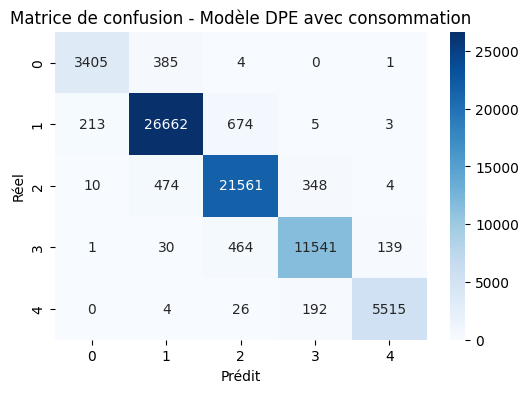

In [13]:
# Rapport détaillé
print("\nClassification report :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Matrice de confusion - Modèle DPE avec consommation")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


Le modèle “DPE avec conso” atteint une précision quasi parfaite (≈ 96 %).
- Il est beaucoup plus performant que le modèle DPE sans consommation .
- Cela valide la logique du chaînage :
    - prédire la consommation (conso_m2)
    - utiliser cette prédiction pour inférer la classe DPE

### 05. Visualisations avancées RandomForest

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20384\2698019994.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


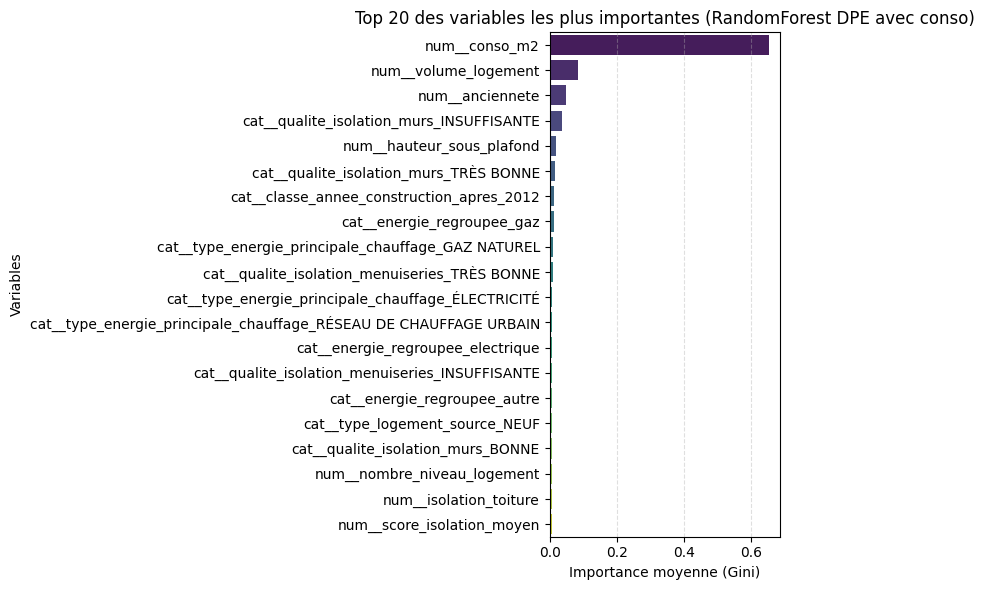

C:\Users\km_sa\AppData\Local\Temp\ipykernel_20384\2698019994.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")


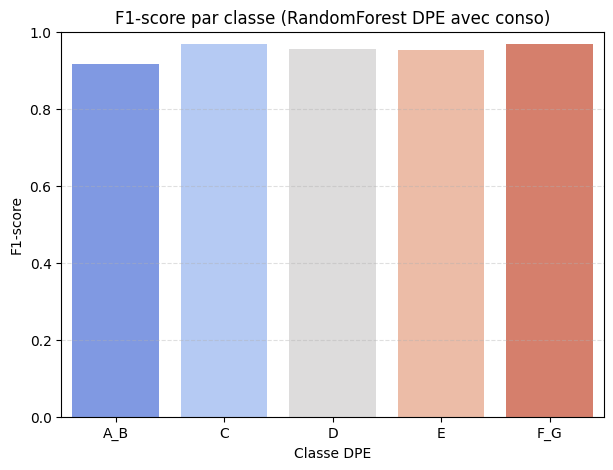

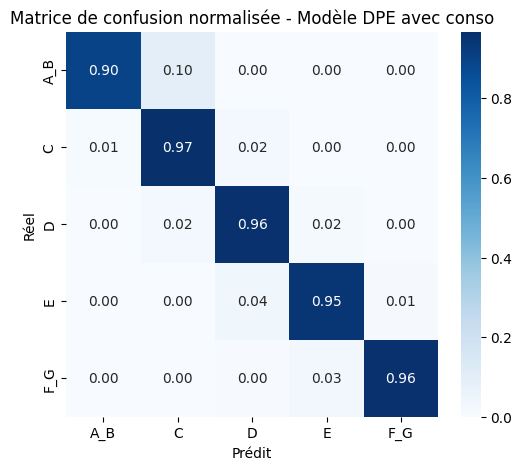

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1️Importance des features
importances = rf_dpe_conso.named_steps["classifier"].feature_importances_
feature_names = rf_dpe_conso.named_steps["preprocessor"].get_feature_names_out()
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Top 20 des variables les plus importantes (RandomForest DPE avec conso)")
plt.xlabel("Importance moyenne (Gini)")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# F1-score par classe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])

plt.figure(figsize=(7,5))
sns.barplot(x=report_df.index, y=report_df["f1-score"], palette="coolwarm")
plt.title("F1-score par classe (RandomForest DPE avec conso)")
plt.ylabel("F1-score")
plt.xlabel("Classe DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

# Matrice de confusion normalisée
cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=rf_dpe_conso.classes_, yticklabels=rf_dpe_conso.classes_)
plt.title("Matrice de confusion normalisée - Modèle DPE avec conso")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


In [19]:
import joblib
import json
import os

# Dossier de sauvegarde
save_dir = "../models/DPE-Avec Conso"
os.makedirs(save_dir, exist_ok=True)

# Fichiers de sortie
model_path = os.path.join(save_dir, "rf_dpe_conso_predictif.joblib")
features_path = os.path.join(save_dir, "rf_dpe_conso_features.json")

# 1. Sauvegarde du pipeline complet
joblib.dump(rf_dpe_conso, model_path)
print(f" Modèle sauvegardé : {model_path}")

# 2. Sauvegarde des noms de features
feature_names = rf_dpe_conso.named_steps["preprocessor"].get_feature_names_out().tolist()
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print(f" Liste des variables sauvegardée : {features_path}")


 Modèle sauvegardé : ../models/DPE-Avec Conso\rf_dpe_conso_predictif.joblib
 Liste des variables sauvegardée : ../models/DPE-Avec Conso\rf_dpe_conso_features.json
